In [1]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set seaborn style
sns.set() 

In [2]:
def ajustar_polinomio_gls(x, y, cov, grado):
    """
    Realiza un ajuste polinómico utilizando Mínimos Cuadrados Generalizados (GLS).
    
    A diferencia de los mínimos cuadrados ordinarios, este método permite 
    incluir una matriz de covarianza para modelar la incertidumbre y la 
    correlación entre las mediciones de 'y'.
    
    Parámetros
    ----------
    x : array_like, shape (n,)
        Variables independientes (ej. ln de las energías).
    y : array_like, shape (n,)
        Variables dependientes (ej. ln de las eficiencias).
    cov : array_like, shape (n, n)
        Matriz de covarianza de las mediciones 'y'. Debe ser simétrica 
        y definida positiva.
    grado : int
        Grado del polinomio a ajustar (ej. 1 para lineal, 2 para cuadrático).
        
    Retorna
    -------
    parametros : ndarray, shape (grado + 1,)
        Coeficientes del ajuste en orden creciente de potencia: [a, b, c...] 
        para f(x) = a + bx + cx^2...
    cov_params : ndarray, shape (grado + 1, grado + 1)
        Matriz de covarianza estimada de los parámetros ajustados.
        
    Notas
    -----
    La solución analítica es:
    beta = (X.T @ W @ X)^-1 @ X.T @ W @ y
    donde W = cov^-1 (matriz de pesos).
    """
    
    # Asegura que las entradas sean arrays de NumPy
    x = np.asarray(x)
    y = np.asarray(y)
    cov = np.asarray(cov)
    
    # Valida las dimensiones
    if x.shape[0] != y.shape[0] or y.shape[0] != cov.shape[0]:
        raise ValueError("Las dimensiones de x, y y cov no coinciden.")

    # Genera la matriz de Vandermonde
    X = np.vander(x, grado + 1, increasing=True)

    # Cálculo de pesos e inversión
    W = np.linalg.inv(cov)

    # Cálculo de la covarianza de los parámetros (XT W X)^-1
    XTW = X.T @ W
    cov_params = np.linalg.inv(XTW @ X)

    # 6. Cálculo de los parámetros (beta)
    parametros = cov_params @ XTW @ y

    return parametros, cov_params

# Uso los mismos datos que en la notebook "incertezas_correlacionadas"

Verifico que los resultados sean iguales

In [3]:
# Valores medidos
x = np.linspace(2.0, 3.0, 11)
# Valores del patrón
y = np.asarray([2.78, 3.29, 3.29, 3.33, 3.23, 3.69, 3.46, 3.87, 3.62, 3.40, 3.99])
# Incerteza asociada a los 'y', se asume la misma para todos
sig_y = 0.3

# Para graficar conviene asignar la incerteza a cada valor de 'y'
sig_y_vec = sig_y * np.ones(len(y))
cov_y = np.diag(sig_y**2 * np.ones(len(y)))

In [4]:
beta, cov_beta = ajustar_polinomio_gls(x, y, cov_y, 1)
# Resultados obtenidos de forma analíca
#          a_hat = 1.45 +/- 0.72
#          b_hat = 0.80 +/- 0.29
#          cov = 
#          [[ 0.51954545 -0.20454545]
#           [-0.20454545  0.08181818]]
print(beta)
print(np.sqrt(np.diag(cov_beta)))
print(cov_beta)

[1.45227273 0.79909091]
[0.72079502 0.28603878]
[[ 0.51954545 -0.20454545]
 [-0.20454545  0.08181818]]


# Ejemplo de ajustes por cuadrados mínimos con incertezas correlacionadas

Calibración en eficiencia de un detector gamma utilizando fuentes que tienen varios picos (Eu-152, Co60). Se agrega a demás una fuente con un sólo pico (Cs-137).

Los datos fueron tomados de mediciones reales, las incertezas fueron simplificadas.

In [5]:
# Energías de los picos analizados [keV]
energias_Eu152 = [
                  244.6974,
                  344.2785,
                  411.1165,
                  778.9045,
                  867.38,
                  964.057,
                 1112.076,
                 1408.013,
]
energias_Co60 = [
                 1173.228,
                 1332.492,
]
energias_Cs137 = [
                  661.657
]

# Tasa de cuentas netas medidas en cada pico [cps]
cps_Eu152 = [
             3.74,
             8.54,
             0.568,
             1.554,
             0.448,
             1.382,
             1.112,
             1.330,
] 
cps_Co60 =[
           9.09,
           7.98,
]
cps_Cs137 = [
             21.31,
]

# Probabiidad de emisión de cada pico (branching ratio)
br_Eu152 = [
            0.0755,
            0.2660,
            0.0224,
            0.1293,
            0.0423,
            0.1451,
            0.1367,
            0.2087,
]
br_Co60 = [
           0.9985,
           0.999826,
]
br_Cs137 = [
    0.851,
]

In [6]:
# Actividades de las fuentes [Bq]
uCi2Bq = 3.7e4  # Conversión de microCi a Bq
actividad_Eu152 = 0.399 * uCi2Bq 
actividad_Co60 = 0.477 * uCi2Bq
actividad_Cs137 = 0.680 * uCi2Bq

In [7]:
# BASE DE DATOS DE ISÓTOPOS
# Se guarda todo en un diccionario para que sea fácil de extraer
# Asumo 3% de error en las actividades y 1% en las tasa de cuentas
data_isopos = {
    'Eu': {
        'energias': energias_Eu152,
        'cps': cps_Eu152,
        'cps_sig': np.asarray(cps_Eu152) * 0.01,
        'br': br_Eu152,
        'actividad': actividad_Eu152,
        'actividad_sig': actividad_Eu152 * 0.03,
    },
    'Co': {
        'energias': energias_Co60,
        'cps': cps_Co60,
        'cps_sig': np.asarray(cps_Co60) * 0.01,
        'br': br_Co60,
        'actividad': actividad_Co60,
        'actividad_sig': actividad_Co60 * 0.03,
    },
    'Cs': {
        'energias': energias_Cs137,
        'cps': cps_Cs137,
        'cps_sig': np.asarray(cps_Cs137) * 0.01,
        'br': br_Cs137,
        'actividad': actividad_Cs137,
        'actividad_sig': actividad_Cs137 * 0.03,
    }
}

In [8]:
# Selección de las fuentes que quiero analizar
#seleccion = ['Eu', 'Co', 'Cs']
#seleccion = ['Eu', 'Co'] 
seleccion = ['Eu'] 

# Contenedores para los datos
cps_list, br_list, ene_list, act_list = [], [], [], []
bloques_cov = []

# Construye la matriz de covarianza por bloques (uno por cada fuente)
for iso in seleccion:
    d = data_isopos[iso]
    n = len(d['cps']) # Cuántos picos tiene esta fuente
    
    # Unir vectores simples
    cps_list.append(d['cps'])
    br_list.extend(d['br'])
    ene_list.extend(d['energias'])
    act_list.extend([d['actividad']] * n)
    
    # Actividades relativas
    sig_actividad_rel = d['actividad_sig'] / d['actividad']
    sig_cps_rel = d['cps_sig'] / d['cps']
   
    # Valores de la diagonal
    val_ii = sig_actividad_rel**2 + sig_cps_rel**2
    # Valores fuera de la diagional
    val_ij = sig_actividad_rel**2                  
   
    # Crea la matriz con todos los valores iguales
    bloque = np.full((n, n), val_ij)
    # Reemplaza la diagional con lo que corresponde
    np.fill_diagonal(bloque, val_ii)
    bloques_cov.append(bloque)


cps = np.concatenate(cps_list)
br = np.array(br_list)
energias = np.array(ene_list)
actividad = np.array(act_list)

# Eficiencia punto a punto
eficiencias = cps / actividad / br

# Construye la matriz de covarianza completa, uniendo todos los bloques
from scipy.linalg import block_diag
cov_ln_eff = block_diag(*bloques_cov)

print(f"Matriz final de {cov_ln_eff.shape[0]}x{cov_ln_eff.shape[1]}")
with np.printoptions(precision=8, linewidth=200):
    print(cov_ln_eff)

Matriz final de 8x8
[[0.001  0.0009 0.0009 0.0009 0.0009 0.0009 0.0009 0.0009]
 [0.0009 0.001  0.0009 0.0009 0.0009 0.0009 0.0009 0.0009]
 [0.0009 0.0009 0.001  0.0009 0.0009 0.0009 0.0009 0.0009]
 [0.0009 0.0009 0.0009 0.001  0.0009 0.0009 0.0009 0.0009]
 [0.0009 0.0009 0.0009 0.0009 0.001  0.0009 0.0009 0.0009]
 [0.0009 0.0009 0.0009 0.0009 0.0009 0.001  0.0009 0.0009]
 [0.0009 0.0009 0.0009 0.0009 0.0009 0.0009 0.001  0.0009]
 [0.0009 0.0009 0.0009 0.0009 0.0009 0.0009 0.0009 0.001 ]]


In [16]:
# Tomo logaritmos naturales
ln_energias = np.log(energias)
ln_eficiencias = np.log(eficiencias)
ln_eficiencias_sig = np.sqrt(np.diag(cov_ln_eff))

<IPython.core.display.Javascript object>


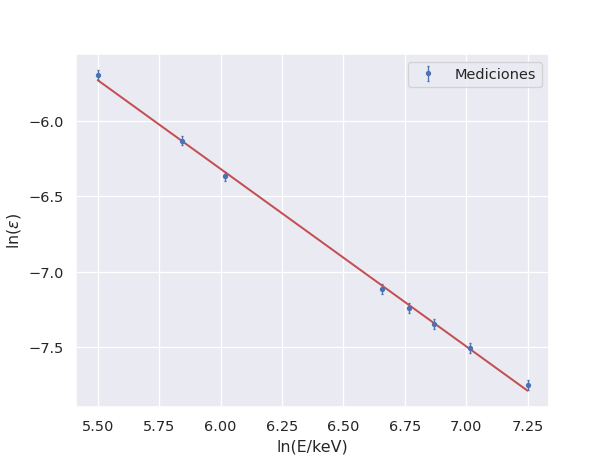

In [17]:
# Grafico mis datos con sus incertezas
fig, ax = plt.subplots()
ax.errorbar(ln_energias, ln_eficiencias, yerr=ln_eficiencias_sig, fmt='.', elinewidth=1, capsize=0.5, label="Mediciones")
ax.set_xlabel("ln(E/keV)")
ax.set_ylabel(r"ln($\epsilon$)")
ax.legend(loc="best")
plt.show()

In [18]:
# No tengo en cuenta la correlación
# Tomo sólo la parte diagonal de la matriz de covarianza, el resto de los términos quedan en cero
# beta, cov_beta = cuadrados_minimos(ln_energias, ln_eficiencias, np.diag(np.diag(cov_ln_eff)), 1)

# Tengo en cuenta a la correlación
beta, cov_beta = ajustar_polinomio_gls(ln_energias, ln_eficiencias, cov_ln_eff, 1)

print(f"{beta=}")
print(f"Sigma parámetros: {np.sqrt(np.diag(cov_beta))}")
print("Covarianza en los parámetros:")
print(cov_beta)

beta=array([ 0.73273262, -1.17505874])
Sigma parámetros: [0.04958493 0.00605889]
Covarianza en los parámetros:
[[ 2.45866496e-03 -2.38243629e-04]
 [-2.38243629e-04  3.67102013e-05]]


In [19]:
# Se grafica el ajuste obtenido
x_fit = np.linspace(ln_energias.min(), ln_energias.max(),100)
y_fit = beta[0] + beta[1] * x_fit

ax.plot(x_fit, y_fit, '-r', label='Ajuste lineal')

#TODO: Agregar bandas de error como en la otra notebook

# Ya tengo la calibración en eficiencia, ahora la voy a aplicar para determinar la eficiencia para cualquier energía

In [20]:
# Modelo de la eficiencia que utilicé
def eficiencia(E):
    return np.exp(beta[0]) * E**beta[1]

$$ ln(\epsilon) = b1 + b2\cdot ln(E)$$

$$ \epsilon(E) = e^{b1} E^{b2}$$

In [21]:
# Eficiencia para E = 411 keV
E_in = 411
eff = eficiencia(E_in)

Para encontrar la incerteza de la efciciencia a esta nueva energía se debe propagar las incertezas de los parámetros.

Usando la fórmula de propagación, y teniendo en cuenta la covarianza entre mis parámetros Cov(b1, b2)
$$\sigma_\epsilon^2 = \epsilon(E)^2 \left[ \sigma_{b1}^2 + (\ln E)^2 \sigma_{b2}^2 + 2 \ln(E)~\text{Cov}(b_1, b_2) \right]$$

In [22]:
parentesis = cov_beta[0, 0] + (np.log(E_in)**2 * cov_beta[1, 1]) + (2 * np.log(E_in) * cov_beta[0, 1])
var_f = (eff**2) * parentesis
std_f = np.sqrt(var_f)

print(f"Eficiencia ({E_in} keV) = {eff:.1e} +/- {std_f:.1e}")
print(f"Error relativo: {std_f / eff * 100:.1f} %")

Eficiencia (411 keV) = 1.8e-03 +/- 5.4e-05
Error relativo: 3.0 %
